In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
df = pd.read_csv('HRR.csv')
print(df.head())

   Age Attribution     BusinessTravel  DailyRate              Department  \
0   41         Yes      Travel_Rarely       1102                   Sales   
1   49          No  Travel_Frequently        279  Research & Development   
2   37         Yes      Travel_Rarely       1373  Research & Development   
3   33          No  Travel_Frequently       1392  Research & Development   
4   27          No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  Gender HourlyRate  JobInvolvement  JobLevel           

In [ ]:
print(df.isnull().sum())
print(df.info())

Age                        0
Attribution                0
BusinessTravel             0
DailyRate                  0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
EmployeeCount              0
EmployeeNumber             0
EnvironmentSatisfaction    0
Gender                     0
HourlyRate                 0
JobInvolvement             0
JobLevel                   0
JobRole                    0
JobSatisfaction            0
MaritalStatus              0
MonthlyIncome              0
MonthlyRate                0
NumCompaniesWorked         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      29 non-null     int64 
 1   Attribution              29 non-null     object
 2   BusinessTravel           29 non-null     object
 3   Daily

In [ ]:
import pandas as pd
print(df[['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate']].describe())

             Age    DailyRate  DistanceFromHome  HourlyRate
count  29.000000    29.000000         29.000000   29.000000
mean   35.620690   842.448276         11.206897   68.793103
std     9.151166   441.833242          8.486878   20.650803
min    21.000000   103.000000          1.000000   31.000000
25%    30.000000   419.000000          3.000000   50.000000
50%    34.000000   809.000000          8.000000   72.000000
75%    38.000000  1282.000000         16.000000   84.000000
max    59.000000  1392.000000         27.000000   96.000000


In [ ]:
age_stats = df.groupby('Attribution')['Age'].agg(['min', 'max', 'mean', 'count']).reset_index()
print(age_stats)

rate_stats = df.groupby('Attribution')['DailyRate'].agg(['min', 'max', 'mean']).reset_index()
print(rate_stats)

  Attribution  min  max       mean  count
0          No   21   59  35.869565     23
1         Yes   28   41  34.666667      6
  Attribution  min   max        mean
0          No  153  1392  817.869565
1         Yes  103  1373  936.666667


In [ ]:
high_value_df = df[['EmployeeNumber', 'Age', 'Department', 'DailyRate']].sort_values(by='DailyRate', ascending=False)
print(high_value_df.head(5))

low_value_df = df[['EmployeeNumber', 'Age', 'Department', 'DailyRate']].sort_values(by='DailyRate', ascending=True)
print(low_value_df.head(5))

    EmployeeNumber  Age              Department  DailyRate
3                5   33  Research & Development       1392
15              20   29  Research & Development       1389
2                4   37  Research & Development       1373
7               11   30  Research & Development       1358
13              18   34  Research & Development       1346
    EmployeeNumber  Age              Department  DailyRate
14              19   28  Research & Development        103
11              15   29  Research & Development        153
8               12   38  Research & Development        216
1                2   49  Research & Development        279
16              21   32  Research & Development        334


In [ ]:
dept_analysis = df.groupby('Department')['DailyRate'].mean().reset_index().sort_values(by='DailyRate', ascending=False)
print(dept_analysis)

               Department  DailyRate
1                   Sales    1057.50
0  Research & Development     808.04


/tmp/ipykernel_1378/2443902943.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Department', y='DailyRate', data=df, errorbar=None, palette='muted')


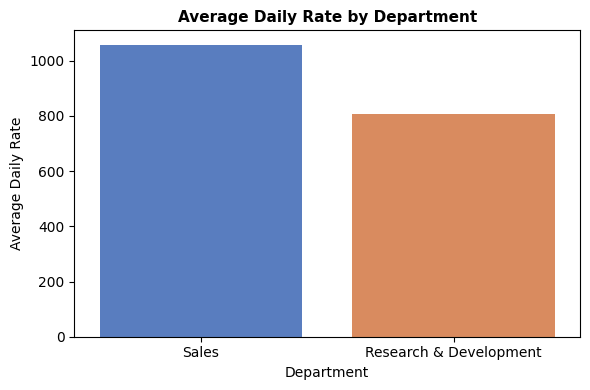

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

 #figsize=(6, 4)
plt.figure(figsize=(6, 4))
sns.barplot(x='Department', y='DailyRate', data=df, errorbar=None, palette='muted')

plt.title('Average Daily Rate by Department', fontsize=11, fontweight='bold')
plt.xlabel('Department', fontsize=10)
plt.ylabel('Average Daily Rate', fontsize=10)
plt.tight_layout()
plt.show()

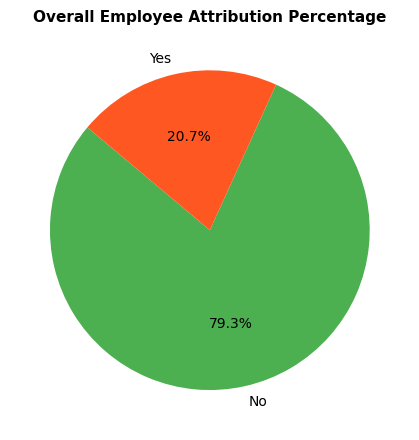

In [ ]:
import matplotlib.pyplot as plt

attribution_counts = df['Attribution'].value_counts()

# figsize=(4.5, 4.5)
plt.figure(figsize=(4.5, 4.5))
plt.pie(attribution_counts, labels=attribution_counts.index, autopct='%1.1f%%', startangle=140, colors=['#4CAF50', '#FF5722'])

plt.title('Overall Employee Attribution Percentage', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

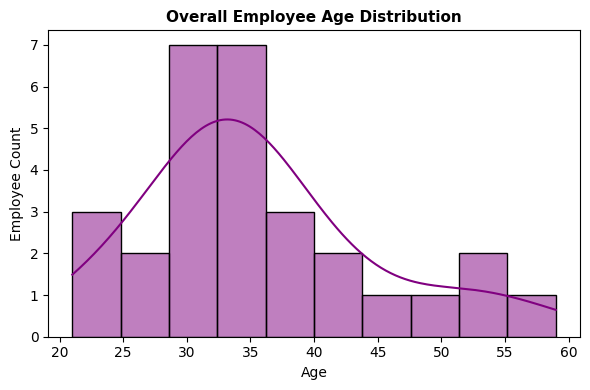

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.histplot(df['Age'], bins=10, kde=True, color='purple')

plt.title('Overall Employee Age Distribution', fontsize=11, fontweight='bold')
plt.xlabel('Age', fontsize=10)
plt.ylabel('Employee Count', fontsize=10)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1378/3060205465.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='EducationField', data=df, order=df['EducationField'].value_counts().index, palette='plasma')


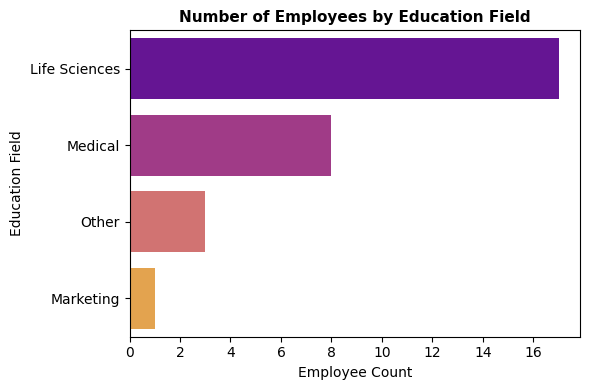

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(y='EducationField', data=df, order=df['EducationField'].value_counts().index, palette='plasma')

plt.title('Number of Employees by Education Field', fontsize=11, fontweight='bold')
plt.xlabel('Employee Count', fontsize=10)
plt.ylabel('Education Field', fontsize=10)
plt.tight_layout()
plt.show()